In [1]:
# get macro file from root file
def getMacro(DMCfile):
    f=TFile.Open(DMCfile)
    macro=f.Get("G4SettingsInfoDir/SuperSim_Macro")
    macro.Print()
    
# get versions from root file
def getVersions(DMCfile):
    data = root_numpy.root2array(DMCfile, treename="G4SettingsInfoDir/Versions")
    df = pd.DataFrame(data)
    print(df)

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import matplotlib.patches as mpatches
import numpy as np
#import root_numpy
from ROOT import TH1D, TFile
import glob

Welcome to JupyROOT 6.28/10


(-10, 310)

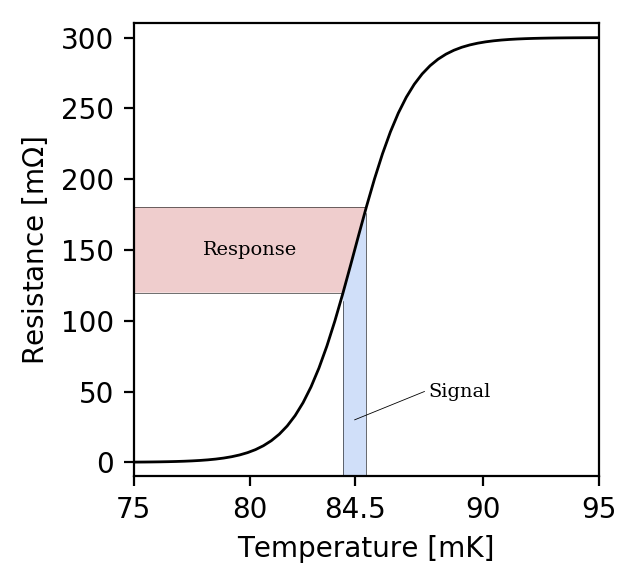

In [3]:
Rn = 300 # mohm
Tw = 2.45 # mK
Tc = 84.5 # mK

T_range = np.linspace(0.8, 1.2, 100) * Tc

R = Rn / 2 * (1 + np.tanh( (T_range - Tc) / Tw) )

plt.figure(figsize=(3,3), dpi = 200)

#plt.fill_betweenx(np.linspace(-500, 500, 10), Tc - Tw, Tc + Tw, facecolor = 'cornflowerblue', alpha = 0.2, edgecolor = 'none')
#plt.axvline(Tc - Tw, 0, 1, color = 'black', lw = 0.3, ls = 'dotted', zorder = -1)
#plt.axvline(Tc + Tw, 0, 1, color = 'black', lw = 0.3, ls = 'dotted', zorder = -1)

Tc_range = np.linspace(84, 85, 100)
Tc_R = Rn / 2 * (1 + np.tanh( (np.linspace(84, 85, 100) - Tc) / Tw) )

plt.fill_between(Tc_range, -300, Tc_R, facecolor = 'cornflowerblue', edgecolor = 'none', alpha = 0.3)
plt.axvline(84, 0, min(Tc_R) / 310, color = 'black', lw = 0.2, ls = '-')
plt.axvline(85, 0, max(Tc_R) / 310, color = 'black', lw = 0.2, ls = '-')

Tc_y = np.linspace(np.min(Tc_R), np.max(Tc_R), 100)
Tc_x = Tc - Tw * np.arctanh(1 - (2 * Tc_y)/Rn)

plt.fill_betweenx(Tc_y, -300, Tc_x, facecolor = 'indianred', edgecolor = 'none', alpha = 0.3)
plt.axhline(max(Tc_R), 0, (max(Tc_x) - 75) / 20, color = 'black', lw = 0.2, ls = '-')
plt.axhline(min(Tc_R), 0, (min(Tc_x) - 75) / 20, color = 'black', lw = 0.2, ls = '-')

plt.plot(T_range, R, color='black', lw = 1)

plt.xlabel('Temperature [mK]')
plt.ylabel(r'Resistance [$\mathrm{m \Omega}$]')

plt.xticks([75, 80, 84.5, 90, 95], ['75', '80', '84.5', '90', '95'])
#plt.yticks([0, 50, 100, 150, 200, 250, 300], ['0', '50', '100', r'$\mathrm{\Delta R}$', '200', '250', '300'])
#plt.text(84.5, 270, 'Transition\nWidth', color = 'black', 
         #horizontalalignment='center', verticalalignment='center',fontsize = 7, family='serif')
plt.text(80, 150, 'Response', color = 'black', 
         horizontalalignment='center', verticalalignment='center',fontsize = 7, family='serif')
plt.text(89, 50, 'Signal', color = 'black', 
         horizontalalignment='center', verticalalignment='center',fontsize = 7, family='serif')
plt.plot([84.5, 87.5], [30, 50], lw = 0.3, color = 'black')
plt.xlim(75, 95)
plt.ylim(-10, 310)

In [4]:
T0 = 83.45060289045924
Tw = 2.5
Rn = 300
R0 = 300 * 0.45

T0 / Tw *np.sqrt(Rn/R0 - 1)

36.90324510888015

(-10, 310)

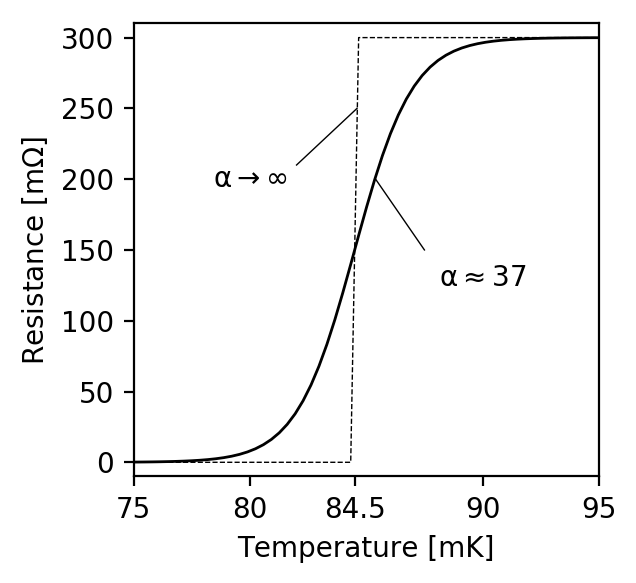

In [5]:
Rn = 300 # mohm
Tw = 2.5 # mK
Tc = 84.5 # mK

T_range = np.linspace(0.8, 1.2, 100) * Tc

plt.figure(figsize=(3,3), dpi = 200)

R = Rn / 2 * (1 + np.tanh( (T_range - Tc) / Tw) )
plt.plot(T_range, R, color='black', lw = 1)
plt.text(90, 130, r'$\mathrm{\alpha \approx 37}$', color = 'black', 
         horizontalalignment='center', verticalalignment='center',fontsize = 10, family='serif')
plt.plot([85.4, 87.5], [200, 150], lw = 0.5, color = 'black')

# alpha -> infinity
R = Rn / 2 * (1 + np.tanh( (T_range - Tc) / 0.001) )
plt.plot(T_range, R, color='black', lw = 0.5, ls = '--')
plt.text(80, 200, r'$\mathrm{\alpha \rightarrow \infty}$', color = 'black', 
         horizontalalignment='center', verticalalignment='center',fontsize = 10, family='serif')
plt.plot([84.6, 82], [250, 210], lw = 0.5, color = 'black')

plt.xlabel('Temperature [mK]')
plt.ylabel(r'Resistance [$\mathrm{m \Omega}$]')

plt.xticks([75, 80, 84.5, 90, 95], ['75', '80', '84.5', '90', '95'])

plt.xlim(75, 95)
plt.ylim(-10, 310)

In [6]:
import pickle
import joblib

filename_default_template='/scratch/user/perry5334/notebooks/HVeV_TESParams/samples/Templates_8192.pkl'
Templates=joblib.load(filename_default_template) 

In [7]:
def getTES(file):
    #### Retrieving the TES traces for each channel ####
    tes1, tes2 = [], []
    data = root_numpy.root2array(file, treename="G4SimDir/g4dmcTES", 
                             branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(0, 0))
    
    for i in range(len(data)):
        if data['ChanName'][i] == b'Ch1':
            tes1.append(data['Trace'][i])
        if data['ChanName'][i] == b'Ch2':
            tes2.append(data['Trace'][i])
        
    tes1, tes2 = np.array(tes1), np.array(tes2)
    
    return tes1, tes2

In [8]:
def getVb(DMCfile):
    v1, v2 = [], []
    #### Retrieving the TES traces for each channel ####
    data = root_numpy.root2array(DMCfile, treename="G4SimDir/g4dmcTES", 
                                 branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(2, 0))
    
    nEvt = len(np.unique(data['EventNum']))
    for event in range(len(data)):
        if data['ChanName'][event][:3] == b'Ch1':
            v1.append(data['Trace'][event])
        if data['ChanName'][event][:3] == b'Ch2':
            v2.append(data['Trace'][event])
        
    v1, v2 = np.array(v1), np.array(v2)
    
    
    return v1, v2

In [9]:
def getTES_A(DMCfile):
    A1, A2 = [], []
    #### Retrieving the TES traces for each channel ####
    data = root_numpy.root2array(DMCfile, treename="G4SimDir/g4dmcTES", 
                                 branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(3, 0))
    
    nEvt = len(np.unique(data['EventNum']))
    for event in range(len(data)):
        if data['ChanName'][event][:3] == b'Ch1':
            A1.append(data['Trace'][event])
        if data['ChanName'][event][:3] == b'Ch2':
            A2.append(data['Trace'][event])
        
    A1, A2 = np.array(A1), np.array(A2)
    
    A1 = np.array([np.sum(A1[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    A2 = np.array([np.sum(A2[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    
    
    return A1, A2

In [10]:
def getPowerIn(DMCfile):
    pow1, pow2 = [], []
    #### Retrieving the TES traces for each channel ####
    data = root_numpy.root2array(DMCfile, treename="G4SimDir/g4dmcTES", 
                                 branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(4, 0))
    
    nEvt = len(np.unique(data['EventNum']))
    for event in range(len(data)):
        if data['ChanName'][event][:3] == b'Ch1':
            pow1.append(data['Trace'][event])
        if data['ChanName'][event][:3] == b'Ch2':
            pow2.append(data['Trace'][event])
        
    pow1, pow2 = np.array(pow1), np.array(pow2)
    
    pow1 = np.array([np.sum(pow1[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    pow2 = np.array([np.sum(pow2[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    
    
    return pow1, pow2

In [11]:
def getTES_G(DMCfile):
    G1, G2 = [], []
    #### Retrieving the TES traces for each channel ####
    data = root_numpy.root2array(DMCfile, treename="G4SimDir/g4dmcTES", 
                                 branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(10, 0))
    
    nEvt = len(np.unique(data['EventNum']))
    for event in range(len(data)):
        if data['ChanName'][event][:3] == b'Ch1':
            G1.append(data['Trace'][event])
        if data['ChanName'][event][:3] == b'Ch2':
            G2.append(data['Trace'][event])
        
    G1, G2 = np.array(G1), np.array(G2)
    
    G1 = np.array([1 / np.sum(G1[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    G2 = np.array([1 / np.sum(G2[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    
    return G1, G2

In [12]:
def getTES_R(DMCfile):
    R1, R2 = [], []
    #### Retrieving the TES traces for each channel ####
    data = root_numpy.root2array(DMCfile, treename="G4SimDir/g4dmcTES", 
                                 branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(11, 0))
    
    nEvt = len(np.unique(data['EventNum']))
    for event in range(len(data)):
        if data['ChanName'][event][:3] == b'Ch1':
            R1.append(data['Trace'][event])
        if data['ChanName'][event][:3] == b'Ch2':
            R2.append(data['Trace'][event])
        
    R1, R2 = np.array(R1), np.array(R2)
    
    R1 = np.array([1 / np.sum(1 / R1[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    R2 = np.array([1 / np.sum(1 / R2[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    
    return R1, R2

In [13]:
def getTES_T(DMCfile):
    T1, T2 = [], []
    #### Retrieving the TES traces for each channel ####
    data = root_numpy.root2array(DMCfile, treename="G4SimDir/g4dmcTES", 
                                 branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(12, 0))
    
    nEvt = len(np.unique(data['EventNum']))
    for event in range(len(data)):
        if data['ChanName'][event][:3] == b'Ch1':
            T1.append(data['Trace'][event])
        if data['ChanName'][event][:3] == b'Ch2':
            T2.append(data['Trace'][event])
        
    T1, T2 = np.array(T1), np.array(T2)
    
    T1_tot = np.array([np.mean(T1[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    T2_tot = np.array([np.mean(T2[36 * i: 36 * (i + 1)], axis = 0) for i in range(nEvt)])
    
    return T1, T2, T1_tot, T2_tot

In [14]:
def getTES_Tc(DMCfile):
    Tc1, Tc2 = [], []
    #### Retrieving the TES traces for each channel ####
    data = root_numpy.root2array(DMCfile, treename="G4SimDir/g4dmcTES", 
                                 branches = ['EventNum','Trace', 'ChanName', 'DataType'], 
                                 selection = 'DataType == {} && EventNum == {}'.format(13, 0))
    
    nEvt = len(np.unique(data['EventNum']))
    for event in range(len(data)):
        if data['ChanName'][event][:3] == b'Ch1':
            Tc1.append(data['Trace'][event])
        if data['ChanName'][event][:3] == b'Ch2':
            Tc2.append(data['Trace'][event])
        
    Tc1, Tc2 = np.array(Tc1), np.array(Tc2)
    
    return Tc1, Tc2

In [14]:
file = '/scratch/user/perry5334/notebooks/Power_studies/optimized_51230729_000000.root'
#file = 'NF-C-100eV_10230617_0000.root'
#file = 'NF-C-100eV_51230801_000000.root'
#file = 'NF-C-1keV_10230617_0000.root'
#file = '/home/kelsey/data/TES_power/NF-C_Single/power-HVeV-1keV-single_10230606_0000.root'
#file = '/home/kelsey/data/TES_power/NF-C_Single/power-HVeV-1keV-IcFactor1_10230607_0000.root'

In [16]:
getVersions(file)

                    SuperSim                         Geant4        ROOT  \
0  b'elog/1669-50-gfeabd43d'  b'geant4-10-06-patch-02 [MT]'  b'6.18/02'   

          G4CMP  RadSrc     CVODE              wimp_sim  \
0  b'G4CMP-325'  b'1.6'  b'5.1.0'  b'wimpsim-V02-00-02'   

                           EPotFiles      SimWorkFlowTools  \
0  b'epotfiles-V00-00-06-0-gf513e20'  b'v5.4.3-0-g155104f'   

             SimProdMacros  
0  b'V01-06-00-1-g553fe52'  


In [17]:
d = {}
phononBins = np.arange(-9830400.0, -9830400.0 + 24576 * 800, 800) * 1e-3
d['tes1'], d['tes2'] = getTES(file)
d['V1'], d['V2'] = getVb(file)
d['A1'], d['A2'] = getTES_A(file)
d['PowerIn1'], d['PowerIn2'] = getPowerIn(file)
d['G1'], d['G2'] = getTES_G(file)
d['R1'], d['R2'] = getTES_R(file)
d['T1'], d['T2'], _, _ = getTES_T(file)
d['Tc1'], d['Tc2'] = getTES_Tc(file)

In [18]:
data = root_numpy.root2array(file, treename="G4SimDir/g4dmcEvent", selection = 'EventNum == {}'.format(0))
PhononE1 = data['PhononE'][0][0]
PhononE2 = data['PhononE'][0][1]
PhononE = PhononE1 + PhononE2

In [19]:
print(PhononE1)
print(PhononE2)
print(PhononE1 + PhononE2)

51.18168978418683
50.76829723330437
101.9499870174912


In [20]:
phononBins = phononBins[2500:]
PowerIn = d['PowerIn1'][0][2500:]
I_TES = d['tes1'][0][2500:]
R_TES = d['R1'][0][2500:]

Ts, Tcs = [], []
for i in range(len(d['T1'])):
    Ts.append(d['T1'][i][2500:])
    Tcs.append(d['Tc1'][i][2500:])
    
Ts, Tcs = np.array(Ts), np.array(Tcs)
zero = phononBins.tolist().index(0)

binWidth = 0.8 # us
aJ2eV = 6.241509744511500288 # eV / aJ
kappa = 8.352e-08 # W / K^5
Tsubst = 67.5e-3 # K

10.250262492143667
51.18169058281238


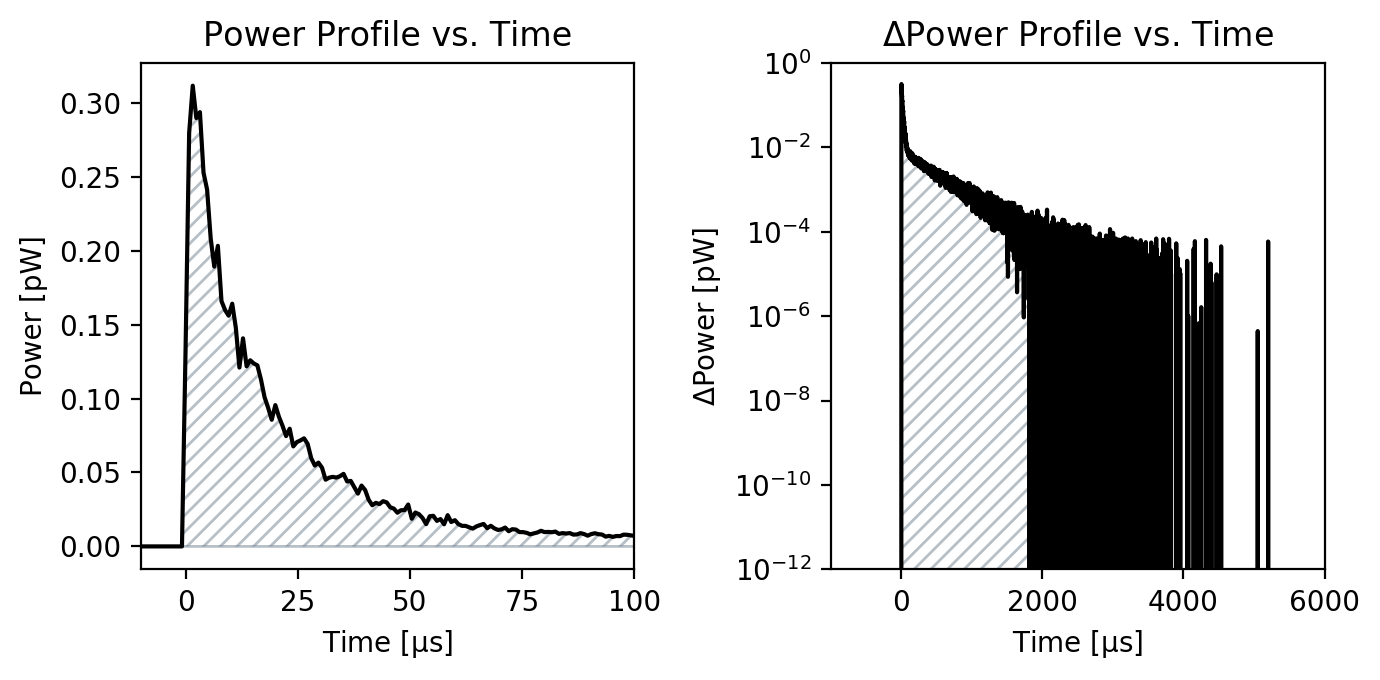

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    data = PowerIn*1e12 # pW
    baseline = np.mean(data[:zero-100])
    delta_data = data - baseline
    
    currentAxis.plot(phononBins, [data, delta_data][plot], color = 'black')
    currentAxis.fill_between(phononBins, [baseline, 0][plot], [data, delta_data][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.set_xlabel(r'Time [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(['', r'$\Delta$'][plot] + r'Power [pW]')
    currentAxis.set_title(['', r'$\Delta$'][plot] + r'Power Profile vs. Time')
    currentAxis.set_xlim([-10, -1000][plot], [100, 6000][plot])
    currentAxis.set_ylim([None, 1e-12][plot], [None, 1e0][plot])
    currentAxis.set_yscale(['linear', 'log'][plot])
    
plt.tight_layout()

print(sum(data))
print(sum(data * binWidth * aJ2eV))

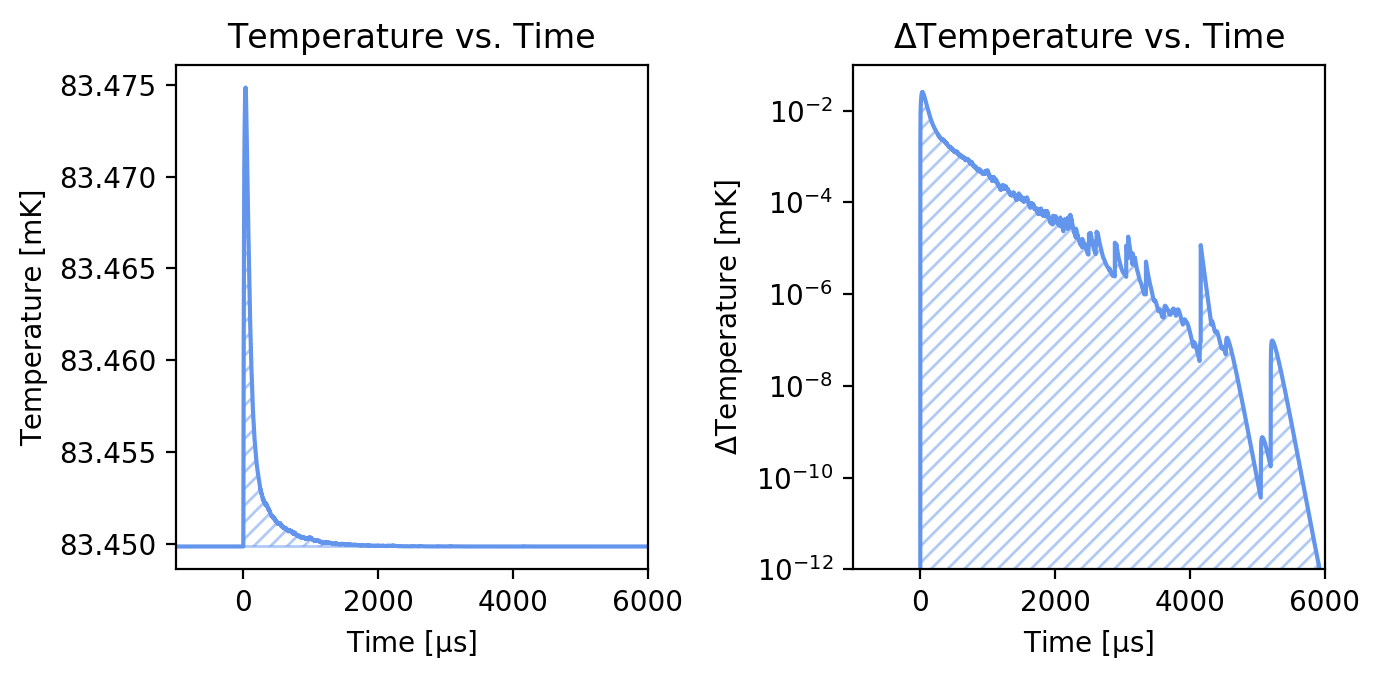

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    data = Ts[0] * 1e3 # mK
    baseline = np.mean(data[:zero-100])
    delta_data = data - baseline
    
    currentAxis.plot(phononBins, [data, delta_data][plot], color = 'cornflowerblue')
    currentAxis.fill_between(phononBins, [baseline, 0][plot], [data, delta_data][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'cornflowerblue', alpha = 0.5)
    
    currentAxis.set_xlabel(r'Time [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(['', r'$\Delta$'][plot] + r'Temperature [mK]')
    currentAxis.set_title(['', r'$\Delta$'][plot] + r'Temperature vs. Time')
    currentAxis.set_xlim(-1000, 6000)
    currentAxis.set_yscale(['linear', 'log'][plot])
    currentAxis.set_ylim([None, 1e-12][plot], [None, 1e-1][plot])
    
plt.tight_layout()

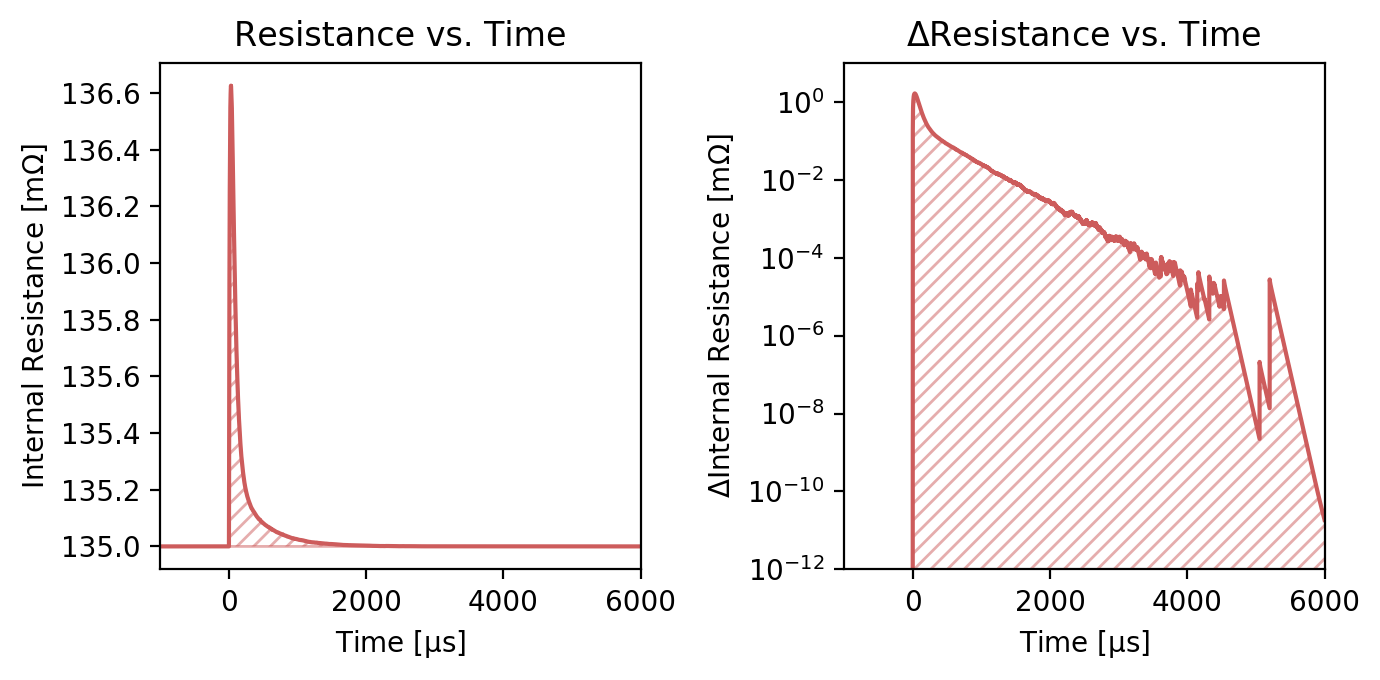

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    data = R_TES * 1e3 # mohm
    baseline = np.mean(data[:zero - 100])
    delta_data = data - baseline
    
    currentAxis.plot(phononBins, [data, delta_data][plot], color = 'indianred')
    currentAxis.fill_between(phononBins, [baseline, 0][plot], [data, delta_data][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'indianred', alpha = 0.5)
    
    currentAxis.set_xlabel(r'Time [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(['', r'$\Delta$'][plot] + r'Internal Resistance [$\mathrm{m \Omega}$]')
    currentAxis.set_title(['', r'$\Delta$'][plot] + r'Resistance vs. Time')
    currentAxis.set_xlim(-1000, 6000)
    currentAxis.set_ylim([None, 1e-12][plot], [None, 1e1][plot])
    currentAxis.set_yscale(['linear', 'log'][plot])
    
plt.tight_layout()

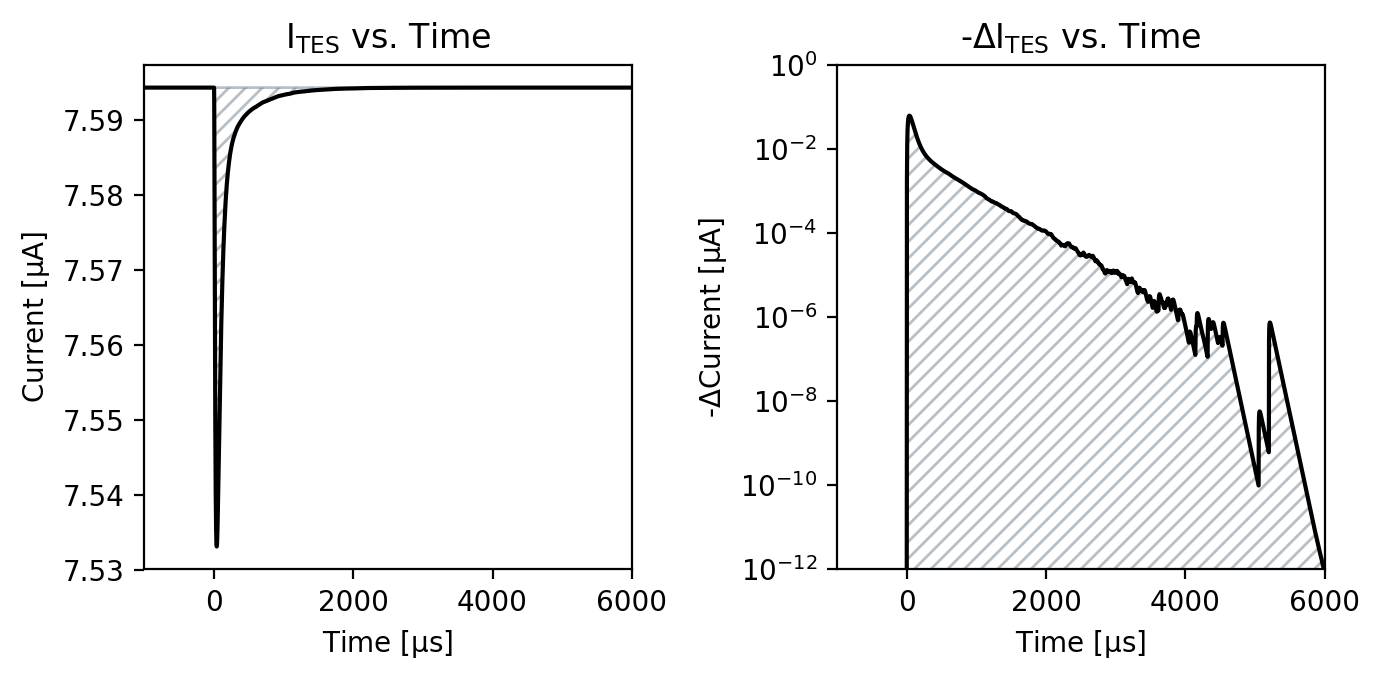

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    data = I_TES # uA
    baseline = np.mean(data[:zero-100])
    delta_data = baseline - data
    
    currentAxis.plot(phononBins, [data, delta_data][plot], color = 'black')
    currentAxis.fill_between(phononBins, [baseline, 0][plot], [data, delta_data][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.set_xlabel(r'Time [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(['', r'-$\Delta$'][plot] + r'Current [$\mathrm{\mu A}$]')
    currentAxis.set_title(['', r'-$\Delta$'][plot] + r'$\mathrm{I_{TES}}$ vs. Time')
    currentAxis.set_xlim(-1000, 6000)
    currentAxis.set_ylim([None, 1e-12][plot], [None, 1e0][plot])
    currentAxis.set_yscale(['linear', 'log'][plot])
    
plt.tight_layout()

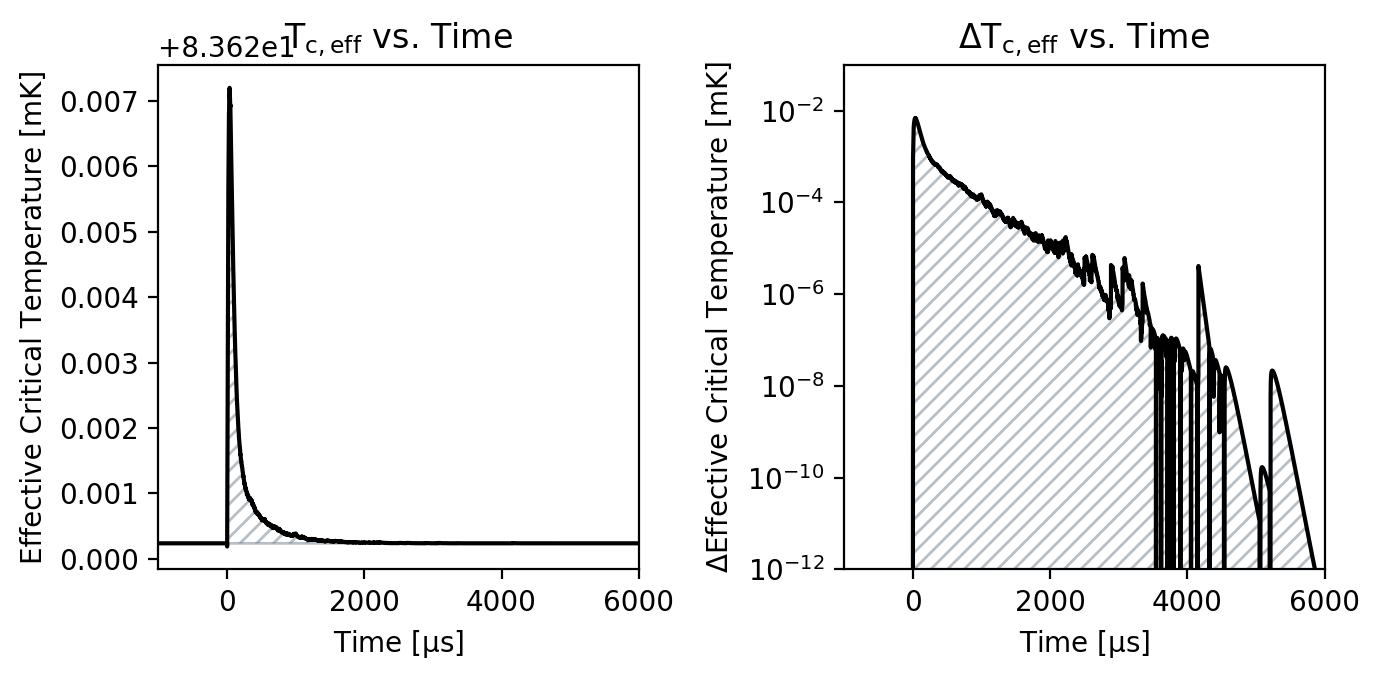

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    data = Tcs[0] * 1e3 # mK
    baseline = np.mean(data[:zero-100])
    delta_data = data - baseline
    
    currentAxis.plot(phononBins, [data, delta_data][plot], color = 'black')
    currentAxis.fill_between(phononBins, [baseline, 0][plot],[data, delta_data][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.set_xlabel(r'Time [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(['', r'$\Delta$'][plot] + r'Effective Critical Temperature [mK]')
    currentAxis.set_title(['', r'$\Delta$'][plot] + r'$\mathrm{T_{c, eff}}$ vs. Time')
    currentAxis.set_xlim(-1000, 6000)
    currentAxis.set_ylim([None, 1e-12][plot], [None, 1e-1][plot])
    currentAxis.set_yscale(['linear', 'log'][plot])
    
plt.tight_layout()

# P = I^2 R

-6.795372907993004 pW => -33.9307089782499 eV

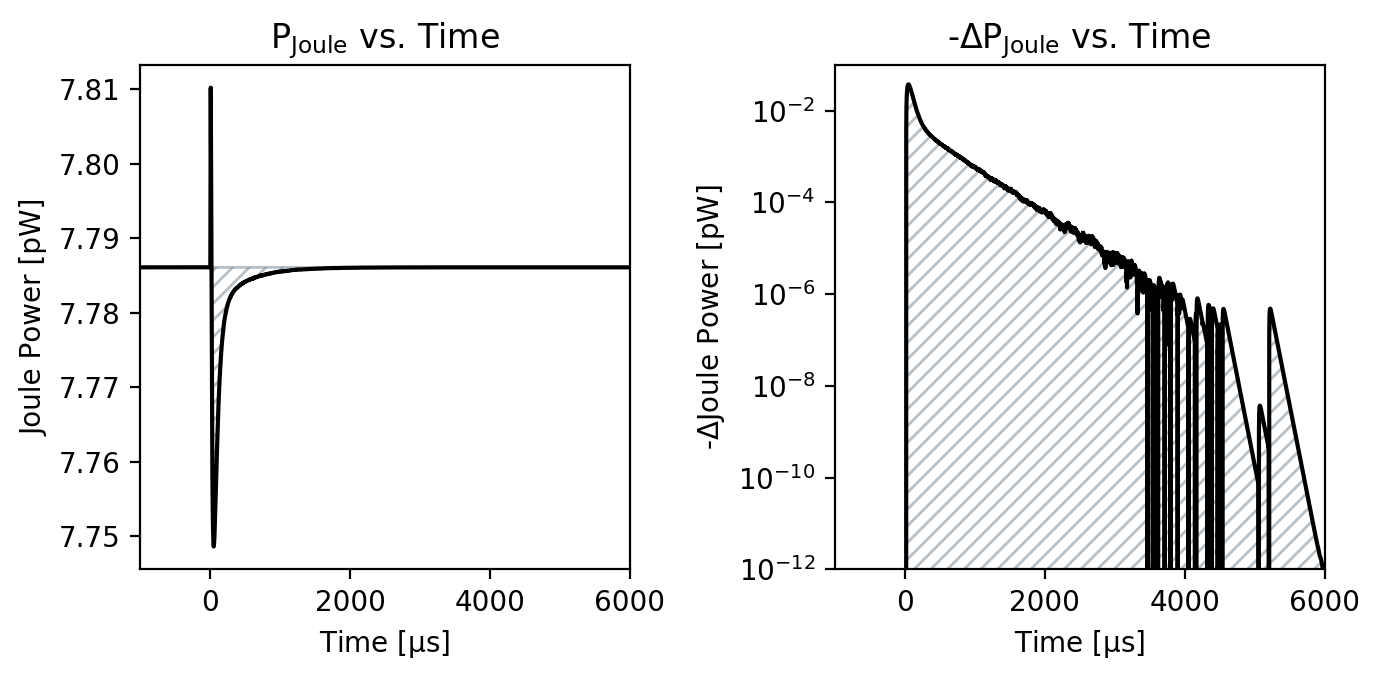

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    
    data = I_TES ** 2 * R_TES
    baseline = np.mean(data[:zero-100])
    delta_data = baseline - data
    
    currentAxis.plot(phononBins, [data, delta_data][plot], color = 'black')
    currentAxis.fill_between(phononBins, [baseline, 0][plot], [data, delta_data][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.set_xlabel(r'Time [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(['', r'-$\Delta$'][plot] + r'Joule Power [pW]')
    currentAxis.set_title(['', r'-$\Delta$'][plot] + r'$\mathrm{P_{Joule}}$ vs. Time')
    currentAxis.set_xlim(-1000, 6000)
    currentAxis.set_yscale(['linear', 'log'][plot])
    currentAxis.set_ylim([None, 1e-12][plot], [None, 1e-1][plot])
    
plt.tight_layout()

print(sum(-delta_data), end = " pW => ")
print(sum(-delta_data * binWidth * aJ2eV), end = " eV")

In [22]:
len(delta_data)

22076

In [23]:
binWidth

0.8

In [24]:
aJ2eV

6.2415097445115

In [89]:
print(sum(delta_data[zero:zero+20] * binWidth * aJ2eV))

-1.356197197402118


0.27012832733025327 pW => 1.3488068698402946 eV

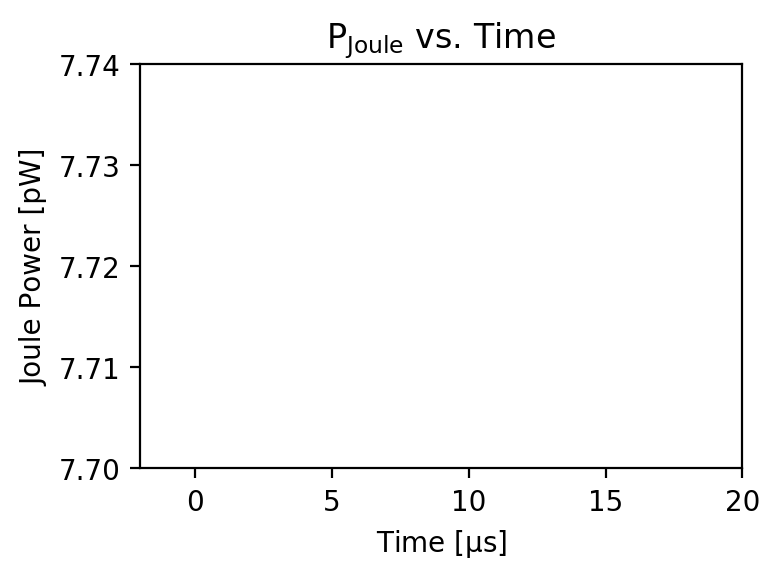

In [90]:
plt.figure(figsize=(4,3), dpi=200)
data = I_TES ** 2 * R_TES # pW
baseline = np.mean(data[:zero])
delta_data = baseline - data
    
plt.plot(phononBins, data, color = 'black')
plt.fill_between(phononBins, baseline, data, facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
plt.xlabel(r'Time [$\mathrm{\mu s}$]')
plt.ylabel(r'Joule Power [pW]')
plt.title(r'$\mathrm{P_{Joule}}$ vs. Time')
plt.xlim(-2, 20)
plt.ylim(7.70, 7.74)
#plt.axvline(phononBins[zero+21], 0, 1)
#plt.axvline(7.436, 0, 1)
    
plt.tight_layout()

print(sum(-delta_data[zero:zero+21]), end = " pW => ")
print(sum(-delta_data[zero:zero+21] * binWidth * aJ2eV), end = " eV")

KeyboardInterrupt: 

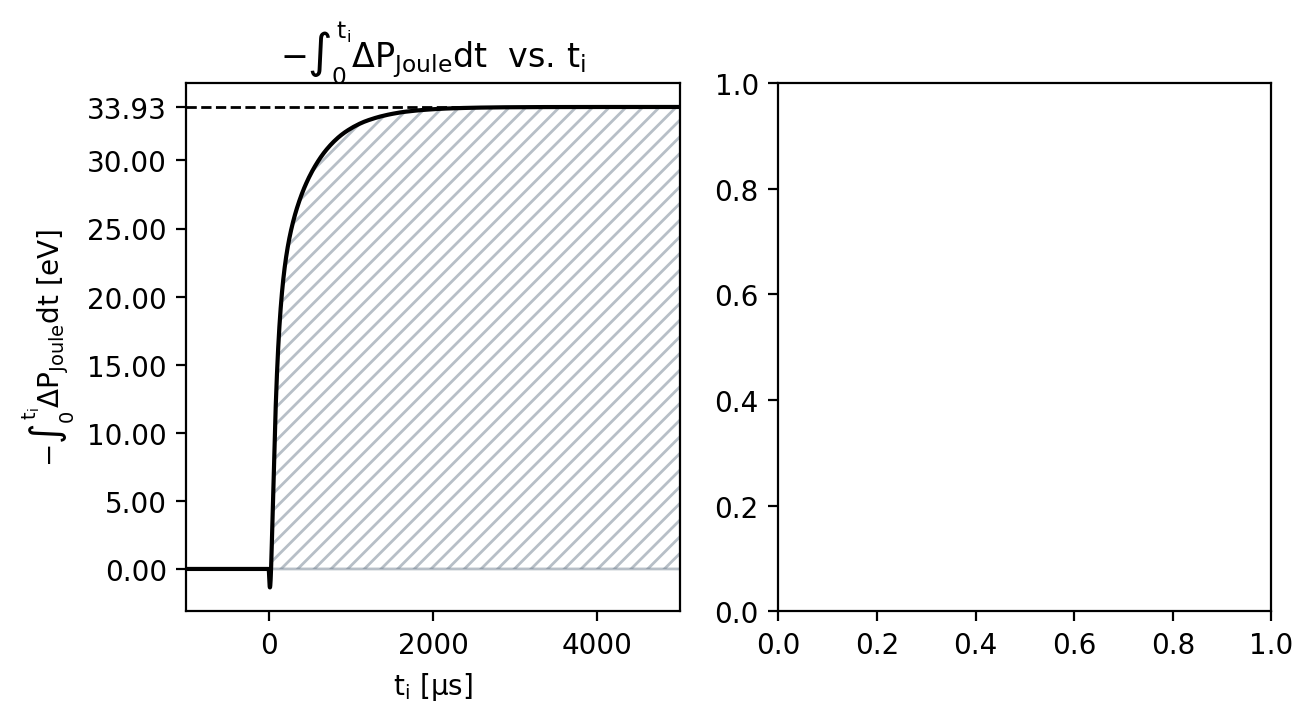

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    data = I_TES ** 2 * R_TES # pW
    baseline = np.mean(data[:zero-100])
    delta_data = baseline - data
    
    running_int = np.array([sum(delta_data[:i] * binWidth * aJ2eV) for i in range(len(delta_data))])
    
    currentAxis.plot(phononBins, [running_int, running_int / PhononE1][plot], color = 'black')
    currentAxis.fill_between(phononBins, 0, [running_int, running_int / PhononE1][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.axhline([running_int[-1], running_int[-1]/PhononE1][plot], 0, 1, lw = 1, ls = '--', color = 'black')
    currentAxis.set_yticks([[0, 5, 10, 15, 20, 25, 30, running_int[-1]], 
                            [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, running_int[-1]/PhononE1]][plot])
    
    currentAxis.set_xlabel(r'$\mathrm{t_i}$ [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(r'$\mathrm{-\int_0^{t_i} \Delta P_{Joule} dt}$ ' + ['[eV]', '/ PhononE'][plot])
    currentAxis.set_title(r'$\mathrm{-\int_0^{t_i} \Delta P_{Joule} dt}$ ' + ['', '/ PhononE'][plot] + r' vs. $\mathrm{t_i}$')
    currentAxis.set_xlim(-1000, 5000)
    
plt.tight_layout()

# Kurinsky Method

In [32]:
def P_joule_kurinsky(tes):
    L = 1450 # nH
    Rs, Rp, Rn_chan, Rb = 50e-3, 10e-3, 300e-3, 2500 # ohm
    RoverRn = 0.45
    I0, Is, delta_Is = np.mean(tes[:zero]), tes, tes - np.mean(tes[:zero]) # uA
    Vb0 = I0 * (Rp + RoverRn*Rn_chan) # uV
    Ibias = Vb0/Rs + I0 # uA

    dIs = np.diff(Is) / 0.8 # uA / us

    delta_Pjoule = (-2 * Is[:-1] * delta_Is[:-1] * (Rp + Rs) # - 2 * Is * delta(Is) * Rload
                    + Ibias * delta_Is[:-1] * Rs # + Ib * delta(Is) * Rshunt
                    - L * delta_Is[:-1] * dIs * 0.001 # - L * delta(Is) * d/dt( Is )
                    - L * Is[:-1] * dIs * 0.001) # - L * Is * d/dt( delta(Is) )
    
    return delta_Pjoule

5.613025567362507 pW => 28.027003019908275 eV

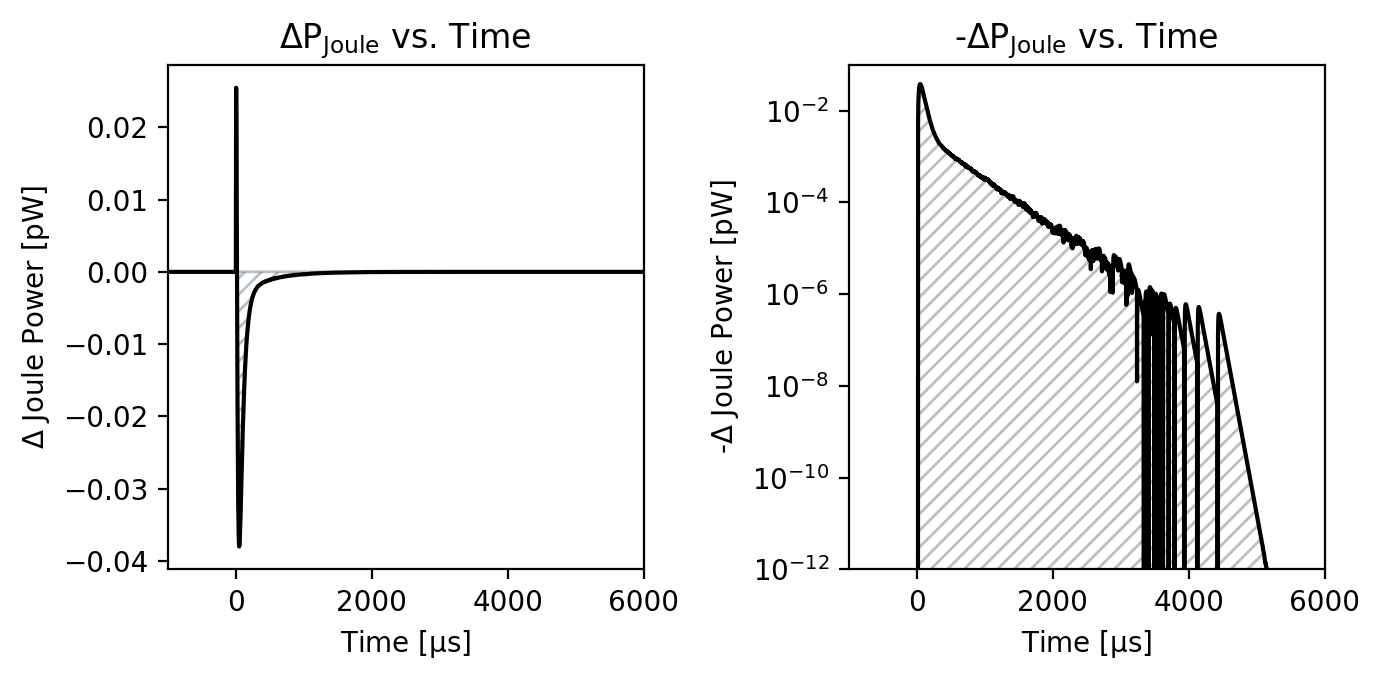

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

data = P_joule_kurinsky(I_TES)
baseline = np.mean(data[:zero-100])
delta_data = data - baseline

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    
    currentAxis.plot(phononBins[:-1], [delta_data, - delta_data][plot], color = 'black')
    currentAxis.fill_between(phononBins[:-1], [baseline, 0][plot], [delta_data, - delta_data][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.set_xlabel(r'Time [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(['', r'-'][plot] + r'$\Delta$ Joule Power [pW]')
    currentAxis.set_title(['', r'-'][plot] + r'$\Delta$$\mathrm{P_{Joule}}$ vs. Time')
    currentAxis.set_xlim(-1000, 6000)
    currentAxis.set_yscale(['linear', 'log'][plot])
    currentAxis.set_ylim([None, 1e-12][plot], [None, 1e-1][plot])
    
plt.tight_layout()
print(sum(-delta_data), end = " pW => ")
print(sum(-delta_data * binWidth * aJ2eV), end = " eV")

In [34]:
(28.027003019908275 - 27.935442646355103) / 27.935442646355103

0.003277570171780264

# Mast Method

In [35]:
def P_joule_mast(tes):
    L = 1450 # nH
    Rs, Rp, Rn_chan, Rb = 50e-3, 10e-3, 300e-3, 2500 # ohm
    RoverRn = 0.45
    I0, Is, delta_Is = np.mean(tes[:zero]), tes, tes - np.mean(tes[:zero]) # uA
    Vb0 = I0 * (Rp + RoverRn*Rn_chan) # uV
    Ibias = Vb0/Rs + I0 # uA

    dIs = np.diff(Is) / 0.8 # uA / us

    delta_Pjoule = (- Is[:-1] * delta_Is[:-1] * (Rp + Rs) # - Is * delta(Is) * Rload
                    + Ibias * delta_Is[:-1] * Rs # + Ib * delta(Is) * Rshunt
                    - L * delta_Is[:-1] * dIs * 0.001) # - L * delta(Is) * d/dt( Is )
    
    return delta_Pjoule

10.054360270933918 pW => 50.20351008469047 eV

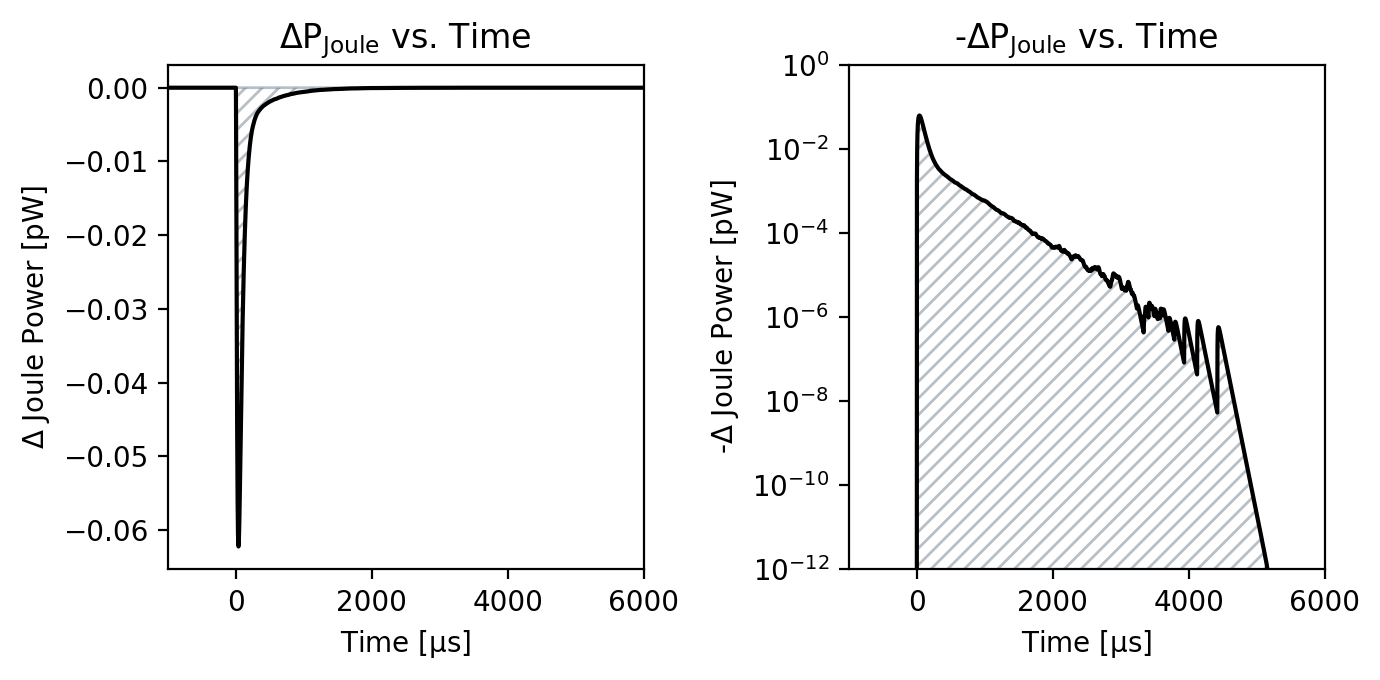

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

data = P_joule_mast(I_TES)
baseline = np.mean(data[:zero])
delta_data = data - baseline

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    
    currentAxis.plot(phononBins[:-1], [delta_data, - delta_data][plot], color = 'black')
    currentAxis.fill_between(phononBins[:-1], [baseline, 0][plot], [delta_data, - delta_data][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.set_xlabel(r'Time [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(['', r'-'][plot] + r'$\Delta$ Joule Power [pW]')
    currentAxis.set_title(['', '-'][plot] + r'$\Delta \mathrm{P_{Joule}}$ vs. Time')
    currentAxis.set_xlim(-1000, 6000)
    currentAxis.set_yscale(['linear', 'log'][plot])
    currentAxis.set_ylim([None, 1e-12][plot], [None, 1e0][plot])
    
plt.tight_layout()
print(sum(-delta_data), end = " pW => ")
print(sum(-delta_data * binWidth * aJ2eV), end = " eV")

In [37]:
(50.20351008469047 - 27.935442646355103) / 27.935442646355103

0.7971259922470142

# Bath Power

In [25]:
def T5diff(a, b):
    b2=b*b
    b3=b2*b
    b4=b3*b
    
    return (a-b) * (a*(a*(a*(a+b) + b2) + b3) + b4)

3.000946105929299 pW => 14.984347490329254 eV

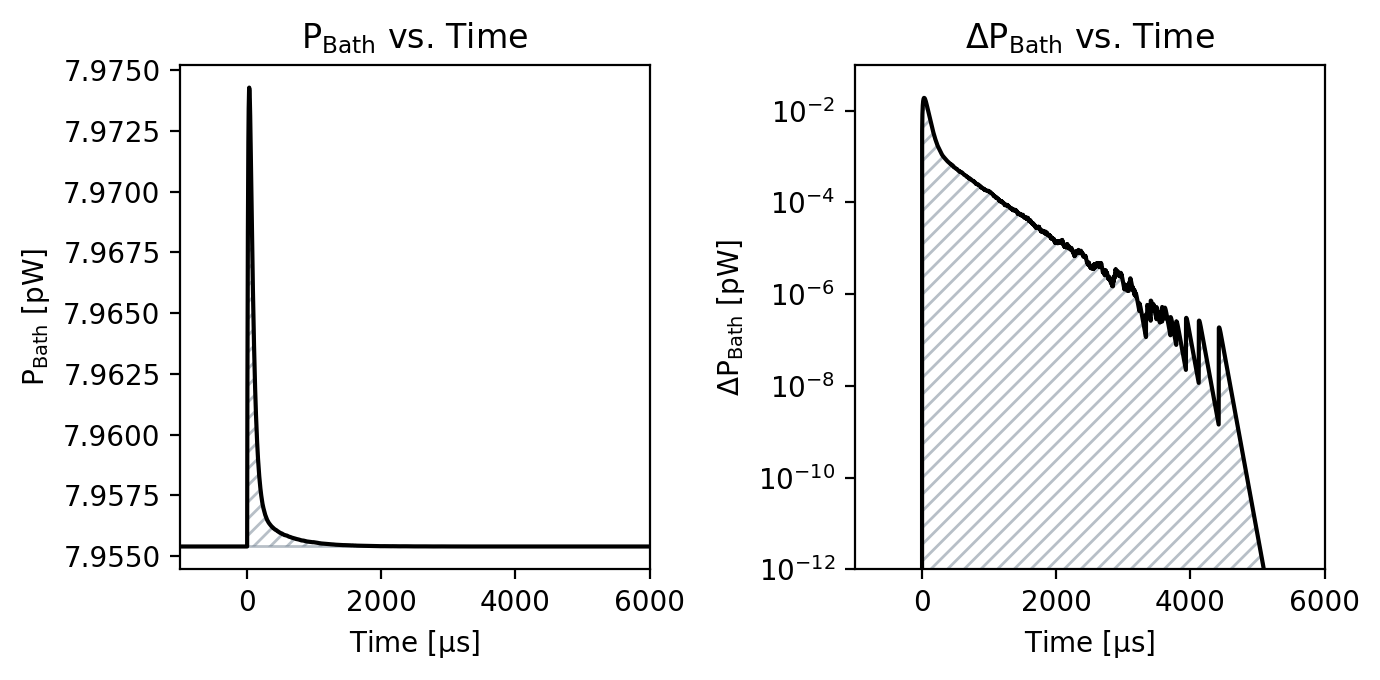

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    data = np.sum(kappa * T5diff(Ts, Tsubst) * 1e12, axis = 0) # pW
    baseline = np.mean(data[:zero-100])
    delta_data = data - baseline
    
    currentAxis.plot(phononBins, [data, delta_data][plot], color = 'black')
    currentAxis.fill_between(phononBins, [baseline, 0][plot], [data, delta_data][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.set_xlabel(r'Time [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(['', r'$\Delta$'][plot] + r'$\mathrm{P_{Bath}}$ [pW]')
    currentAxis.set_title(['', r'$\Delta$'][plot] + r'$\mathrm{P_{Bath}}$ vs. Time')
    currentAxis.set_xlim(-1000, 6000)
    currentAxis.set_yscale(['linear', 'log'][plot])
    currentAxis.set_ylim([None, 1e-12][plot], [None, 1e-1][plot])
    
plt.tight_layout()

print(sum(delta_data), end=' pW => ')
print(sum(delta_data * binWidth * aJ2eV), end = ' eV')

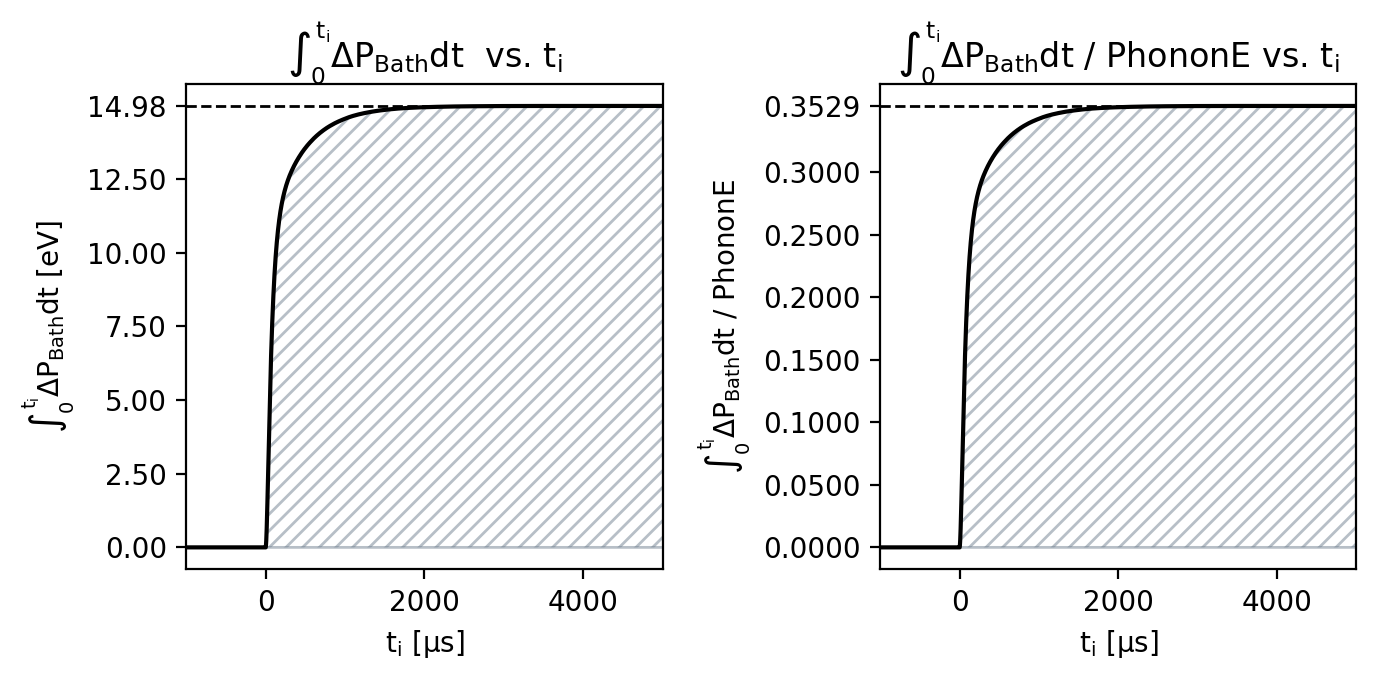

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    data = np.sum(kappa * T5diff(Ts, Tsubst) * 1e12, axis = 0) # pW
    baseline = np.mean(data[:zero-100])
    delta_data = data - baseline
    
    running_int = np.array([sum(delta_data[:i] * binWidth * aJ2eV) for i in range(len(delta_data))])
    
    currentAxis.plot(phononBins, [running_int, running_int / PhononE1][plot], color = 'black')
    currentAxis.fill_between(phononBins, 0, [running_int, running_int / PhononE1][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.axhline([running_int[-1], running_int[-1]/PhononE1][plot], 0, 1, lw = 1, ls = '--', color = 'black')
    currentAxis.set_yticks([[0, 2.5, 5.0, 7.5, 10.0, 12.5, running_int[-1]], 
                            [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, running_int[-1]/PhononE1]][plot])
    
    currentAxis.set_xlabel(r'$\mathrm{t_i}$ [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(r'$\mathrm{\int_0^{t_i} \Delta P_{Bath} dt}$ ' + ['[eV]', '/ PhononE'][plot])
    currentAxis.set_title(r'$\mathrm{\int_0^{t_i} \Delta P_{Bath} dt}$ ' + ['', '/ PhononE'][plot] + r' vs. $\mathrm{t_i}$')
    currentAxis.set_xlim(-1000, 5000)
    
plt.tight_layout()

# Total

8.595634688793474 pW => 42.91979013629261 eV

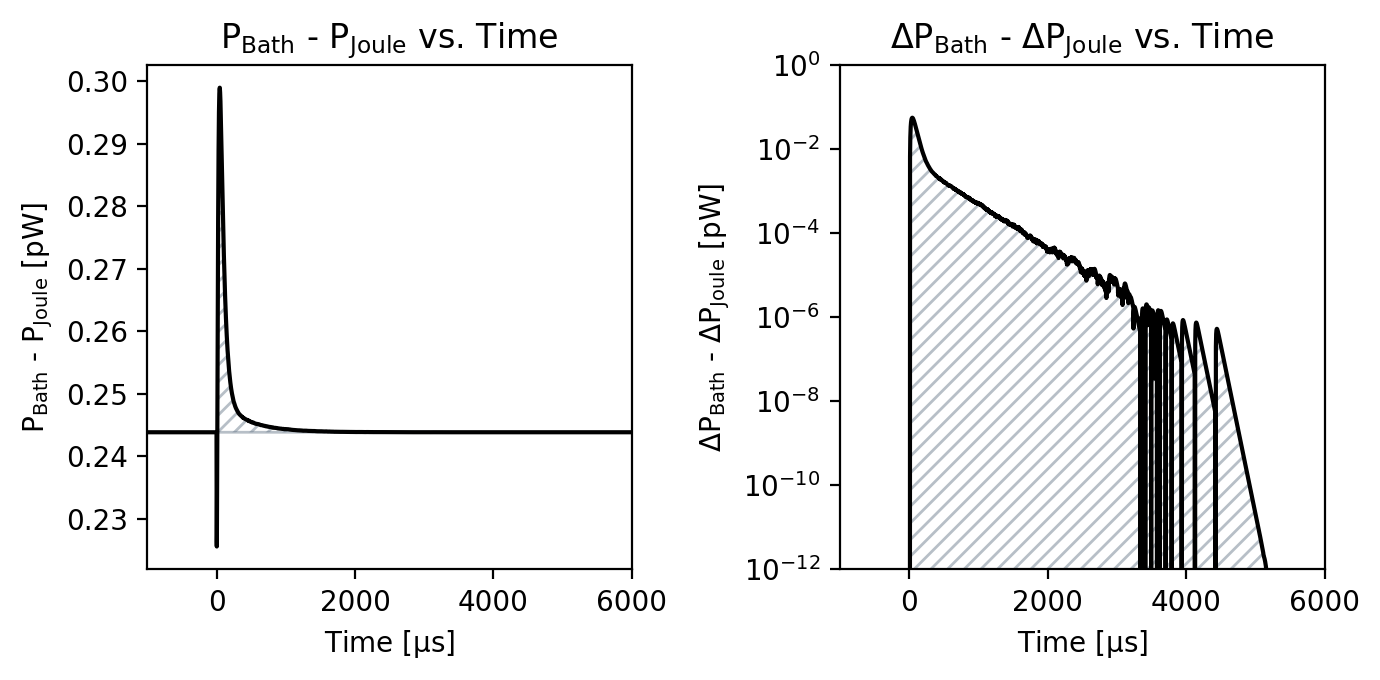

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    
    bath_data = np.sum(kappa * T5diff(Ts, Tsubst) * 1e12, axis = 0) # pW
    bath_baseline = np.mean(bath_data[:zero - 100])
    bath_delta = bath_data - bath_baseline
    
    joule_data = I_TES ** 2 * R_TES # pW
    joule_baseline = np.mean(joule_data[:zero - 100])
    joule_delta = joule_data - joule_baseline
    
    data = bath_data - joule_data
    baseline = np.mean(data[:zero - 100])
    delta_data = data - baseline
    
    currentAxis.plot(phononBins, [data, delta_data][plot], color = 'black')
    currentAxis.fill_between(phononBins, [baseline, 0][plot], [data, delta_data][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.set_xlabel(r'Time [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(['', r'$\Delta$'][plot] + r'$\mathrm{P_{Bath}}$ - ' + ['', r'$\Delta$'][plot] + '$\mathrm{P_{Joule}}$ [pW]')
    currentAxis.set_title(['', r'$\Delta$'][plot] + r'$\mathrm{P_{Bath}}$ - ' + ['', r'$\Delta$'][plot] + '$\mathrm{P_{Joule}}$ vs. Time')
    currentAxis.set_xlim(-1000, 6000)
    currentAxis.set_ylim([None, 1e-12][plot], [None, 1e0][plot])
    currentAxis.set_yscale(['linear', 'log'][plot])
    
plt.tight_layout()

print(sum(delta_data), end=' pW => ')
print(sum(delta_data * binWidth * aJ2eV), end = ' eV')

KeyboardInterrupt: 

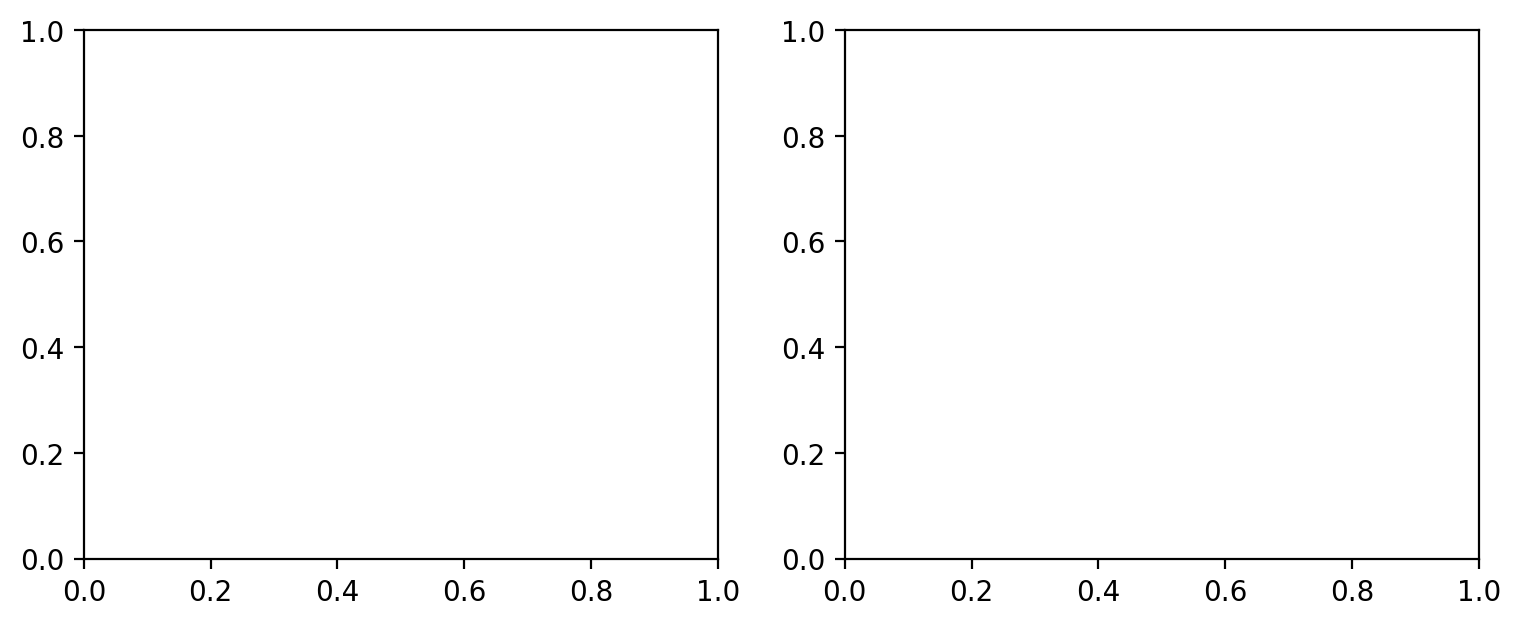

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(10 * 0.9, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    
    bath_data = np.sum(kappa * T5diff(Ts, Tsubst) * 1e12, axis = 0) # pW
    bath_baseline = np.mean(bath_data[:zero - 100])
    bath_delta = bath_data - bath_baseline
    
    joule_data = I_TES ** 2 * R_TES # pW
    joule_baseline = np.mean(joule_data[:zero - 100])
    joule_delta = joule_data - joule_baseline
    
    data = bath_data - joule_data
    baseline = np.mean(data[:zero - 100])
    delta_data = data - baseline
    
    int_tot = np.array([sum(delta_data[:i] * binWidth * aJ2eV) for i in range(len(delta_data))])
    int_joule = np.array([sum(-joule_delta[:i] * binWidth * aJ2eV) for i in range(len(joule_delta))])
    int_bath = np.array([sum(bath_delta[:i] * binWidth * aJ2eV) for i in range(len(bath_delta))])
    
    currentAxis.plot(phononBins, [int_tot, int_tot / PhononE1][plot], color = 'black')
    currentAxis.fill_between(phononBins, 0, [int_tot, int_tot / PhononE1][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5, label = r'$\mathrm{P = \Delta P_{Bath} - \Delta P_{Joule}}$')
    
    currentAxis.plot(phononBins, [int_joule, int_joule / PhononE1][plot], color = 'indianred')
    currentAxis.fill_between(phononBins, 0, [int_joule, int_joule / PhononE1][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'indianred', alpha = 0.5, label = r'$\mathrm{P = - \Delta P_{Joule}}$')
    
    currentAxis.plot(phononBins, [int_bath, int_bath / PhononE1][plot], color = 'cornflowerblue')
    currentAxis.fill_between(phononBins, 0, [int_bath, int_bath / PhononE1][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'cornflowerblue', alpha = 0.5, label = r'$\mathrm{P = \Delta P_{Bath}}$')
    
    currentAxis.axhline([int_tot[-1], int_tot[-1]/PhononE1][plot], 0, 1, lw = 1, ls = '--', color = 'black')
    currentAxis.axhline([int_joule[-1], int_joule[-1]/PhononE1][plot], 0, 1, lw = 1, ls = '--', color = 'indianred')
    currentAxis.axhline([int_bath[-1], int_bath[-1]/PhononE1][plot], 0, 1, lw = 1, ls = '--', color = 'cornflowerblue')
    currentAxis.set_yticks([[0, int_bath[-1], int_joule[-1], int_tot[-1]], 
                            [0, int_bath[-1]/PhononE1, int_joule[-1]/PhononE1, int_tot[-1]/PhononE1]][plot])
    
    currentAxis.set_xlabel(r'$\mathrm{t_i}$ [$\mathrm{\mu s}$]')
    currentAxis.set_ylabel(r'$\mathrm{\int_0^{t_i} P dt}$ ' + ['[eV]', '/ PhononE'][plot])
    currentAxis.set_title(r'$\mathrm{\int_0^{t_i} P dt}$ ' + ['', '/ PhononE'][plot] + ' vs. $\mathrm{t_i}$')
    currentAxis.set_xlim(-1000, 5000)
    
axes.flatten()[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
plt.tight_layout()

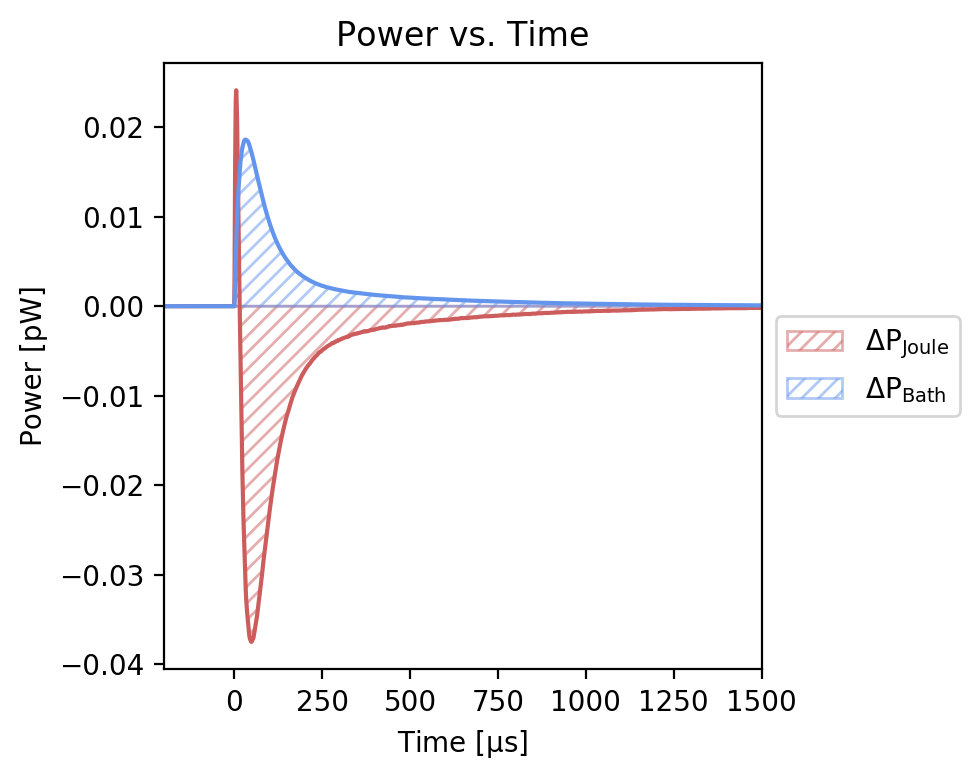

In [27]:
plt.figure(figsize=(5,4), dpi=200)

bath_data = np.sum(kappa * T5diff(Ts, Tsubst) * 1e12, axis = 0) # pW
bath_baseline = np.mean(bath_data[:zero - 100])
bath_delta = bath_data - bath_baseline
    
joule_data = I_TES ** 2 * R_TES # pW
joule_baseline = np.mean(joule_data[:zero - 100])
joule_delta = joule_data - joule_baseline
    
plt.plot(phononBins, joule_delta, color = 'indianred')
plt.fill_between(phononBins, 0, joule_delta, 
                        facecolor = 'none', hatch='////', edgecolor = 'indianred', alpha = 0.5, label = r'$\mathrm{\Delta P_{Joule}}$')
    
plt.plot(phononBins, bath_delta, color = 'cornflowerblue')
plt.fill_between(phononBins, 0, bath_delta, 
                        facecolor = 'none', hatch='////', edgecolor = 'cornflowerblue', alpha = 0.5, label = r'$\mathrm{\Delta P_{Bath}}$')
    
plt.xlabel(r'Time [$\mathrm{\mu s}$]')
plt.ylabel(r'Power [pW]')
plt.title(r'Power vs. Time')
    
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.xlim(-200, 1500)
    
plt.tight_layout()

KeyboardInterrupt: 

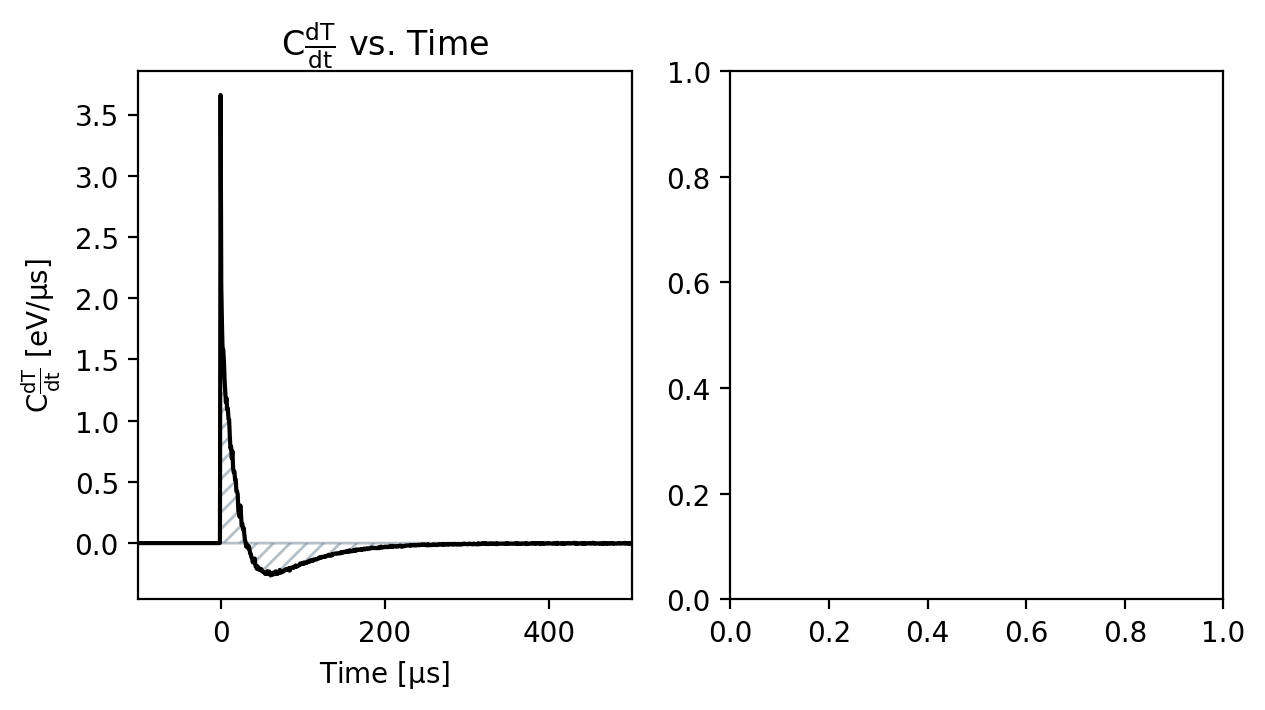

In [44]:
C = 2.43 * 100  * 40e-9 * 84.5e-3 * (522/36) * 2.4e-6 * 150e-6 * aJ2eV * 1e18 # eV / K

fig, axes = plt.subplots(1, 2, figsize=(10 * 0.7, 5 * 0.7), dpi = 200)

for plot in range(2):
    currentAxis = axes.flatten()[plot]
    dT = np.array([np.diff(i) for i in Ts])
    CdT = C * dT
    CdT_all = np.sum(CdT, axis = 0)
    
    running_int = np.array([sum(CdT_all[:i]) for i in range(len(CdT_all))])
    
    currentAxis.plot(phononBins[:-1], [CdT_all/0.8, running_int][plot], color = 'black')
    currentAxis.fill_between(phononBins[:-1], 0, [CdT_all/0.8, running_int][plot], 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
    
    currentAxis.set_xlabel([r'Time [$\mathrm{\mu s}$]', r'$\mathrm{t_i}$ [$\mathrm{\mu s}$]'][plot])
    currentAxis.set_ylabel([r'$\mathrm{C\frac{dT}{dt}}$ [$\mathrm{eV/ \mu s}$]', 
                            r'$\mathrm{\int_0^{t_i} C \frac{dT}{dt} dt}$ [eV]'][plot])
    currentAxis.set_title([r'$\mathrm{C\frac{dT}{dt}}$ vs. Time',
                           r'$\mathrm{\int_0^{t_i} C \frac{dT}{dt} dt}$ vs. $\mathrm{t_i}$'][plot])
    currentAxis.set_xlim([-100,-1000][plot], [500,5000][plot])
    
plt.tight_layout()

# Both Channels

In [ ]:
I_TES1, I_TES2 = d['tes1'][0][2500:], d['tes2'][0][2500:]
R_TES1, R_TES2 = d['R1'][0][2500:], d['R2'][0][2500:]

data1, data2 = I_TES1 ** 2 * R_TES1, I_TES2 ** 2 * R_TES2
baseline1, baseline2 = np.mean(data1[:zero-100]), np.mean(data2[:zero-100])
delta_data1, delta_data2 = baseline1 - data1, baseline2 - data2

EJoule1 = sum(delta_data1 * binWidth * aJ2eV)
EJoule2 = sum(delta_data2 * binWidth * aJ2eV)

In [ ]:
Ts1, Ts2 = [], []
for i in range(len(d['T1'])):
    Ts1.append(d['T1'][i][2500:])
    Ts2.append(d['T2'][i][2500:])
    
Ts1, Ts2 = np.array(Ts1), np.array(Ts2)

data1, data2 = np.sum(kappa * T5diff(Ts1, Tsubst) * 1e12, axis = 0), np.sum(kappa * T5diff(Ts2, Tsubst) * 1e12, axis = 0) # pW
baseline1, baseline2 = np.mean(data1[:zero-100]), np.mean(data2[:zero-100])
delta_data1, delta_data2 = data1 - baseline1, data2 - baseline2

EBath1 = sum(delta_data1 * binWidth * aJ2eV)
EBath2 = sum(delta_data2 * binWidth * aJ2eV)

In [ ]:
print(f'Channel 1 Efficiency: {(EJoule1 + EBath1) / PhononE1 * 100}')
print(f'Channel 2 Efficiency: {(EJoule2 + EBath2) / PhononE2 * 100}')
print(f'Total Efficiency: {(EJoule1 + EBath1 + EJoule2 + EBath2) / PhononE * 100}')

In [ ]:
print(f'Channel 1 Nonconservation: {((EJoule1 + EBath1) - PhononE1) / PhononE1 * 100}')
print(f'Channel 2 Nonconservation: {((EJoule2 + EBath2) - PhononE2) / PhononE2 * 100}')

In [ ]:
print(f'Channel 1 Percent Joule: {(EJoule1) / PhononE1 * 100}')
print(f'Channel 2 Percent Joule: {(EJoule2) / PhononE2 * 100}')
print(f'Total Percent Joule: {(EJoule1 + EJoule2) / PhononE * 100}')

In [ ]:
print(f'Channel 1 Percent Bath: {(EBath1) / PhononE1 * 100}')
print(f'Channel 2 Percent Bath: {(EBath2) / PhononE2 * 100}')
print(f'Total Percent Joule: {(EBath2 + EBath2) / PhononE * 100}')

In [ ]:
print(f'Total Efficiency: {((EJoule1 + EBath1 + EJoule2 + EBath2) - PhononE) / PhononE * 100}')

In [ ]:
EJoule1 + EBath1 + EJoule2 + EBath2

In [ ]:
plt.figure(figsize=(4,3), dpi=200)
tes1 = max(d['tes1'][0][2500:][zero:]) - d['tes1'][0][2500:][zero:]
template1 = Templates['CH3'][4095:]
plt.plot(phononBins[zero:zero+4097], template1, color = 'black', ls = '--')
plt.plot(phononBins[zero:], tes1 / max(tes1), color = 'red')
plt.yscale('log')
plt.xlim(-100, 3000)

In [ ]:
plt.figure(figsize=(4,3), dpi=200)
tes2 = max(d['tes2'][0][2500:][zero:]) - d['tes2'][0][2500:][zero:]
template2 = Templates['CH2'][4095:]
plt.plot(phononBins[zero:zero+4097], template2, color = 'black', ls = '--')
plt.plot(phononBins[zero:], tes2 / max(tes2), color = 'red')
plt.yscale('log')
plt.xlim(-100, 3000)

Text(0.5, 0, 'Time [$\\mathrm{\\mu s}$]')

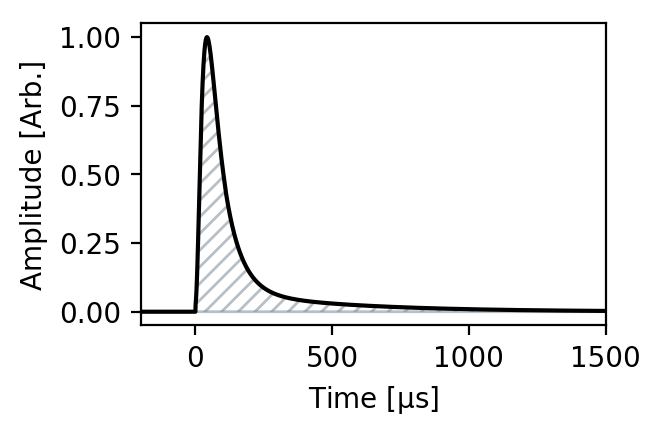

In [61]:
plt.figure(figsize=(3,2), dpi=200)
tes1 = max(d['tes1'][0][2500:][zero:]) - d['tes1'][0][2500:][zero:]
template1 = Templates['CH3'][4095-500:]
plt.plot(phononBins[zero-500:zero+4097], template1, color = 'black', ls = '-')
plt.fill_between(phononBins[zero-500:zero+4097], 0, template1, 
                             facecolor = 'none', hatch='////', edgecolor = 'slategray', alpha = 0.5)
#plt.yscale('log')
plt.xlim(-200, 1500)

plt.ylabel('Amplitude [Arb.]')
plt.xlabel(r'Time [$\mathrm{\mu s}$]')